# Análise do Mercado de Trabalho Formal — CAGED Novo e Ajustado
## Estados do Nordeste (2015–2025)

Este notebook analisa os dados do CAGED (Cadastro Geral de Empregados e Desligados) para os 9 estados do Nordeste brasileiro, combinando:
- **CAGED Antigo** (2015–2019): período pré-eSocial
- **Novo CAGED** (2020–2025): período pós-eSocial

### Dados disponíveis:
- Saldo mensal de emprego formal por UF
- Movimentações por setor econômico (seção CNAE 2.0)
- Perfil dos trabalhadores (sexo e escolaridade)
- Série bimestral harmonizada (2015–2025)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

BASE = '../dados_nordeste/processed/caged/nordeste/'

# Carregar todos os datasets
df_novo = pd.read_csv(BASE + 'caged_saldo_mensal.csv')
df_antigo = pd.read_csv(BASE + 'caged_antigo_saldo_mensal.csv')
df_setor = pd.read_csv(BASE + 'caged_por_setor.csv')
df_perfil = pd.read_csv(BASE + 'caged_por_perfil.csv')
df_bimestral = pd.read_csv(BASE + 'caged_bimestral.csv')
df_antigo_perfil = pd.read_csv(BASE + 'caged_antigo_por_perfil.csv')

# Unificar série mensal (antigo + novo)
df_mensal = pd.concat([df_antigo, df_novo], ignore_index=True)
df_mensal['data'] = pd.to_datetime(df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str) + '-01')
df_mensal.sort_values(['data', 'sigla_uf'], inplace=True)

# Unificar perfil
df_perfil_total = pd.concat([df_antigo_perfil, df_perfil], ignore_index=True)

print(f'Série mensal unificada: {len(df_mensal)} registros')
print(f'Período: {df_mensal.data.min().strftime("%Y-%m")} a {df_mensal.data.max().strftime("%Y-%m")}')
print(f'Estados: {sorted(df_mensal.sigla_uf.unique())}')

Série mensal unificada: 1071 registros
Período: 2015-02 a 2025-12
Estados: ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']


---
## 1. Panorama Geral — Saldo de Emprego Formal no Nordeste

Evolução do saldo agregado (admissões − desligamentos) mensal para toda a região Nordeste.

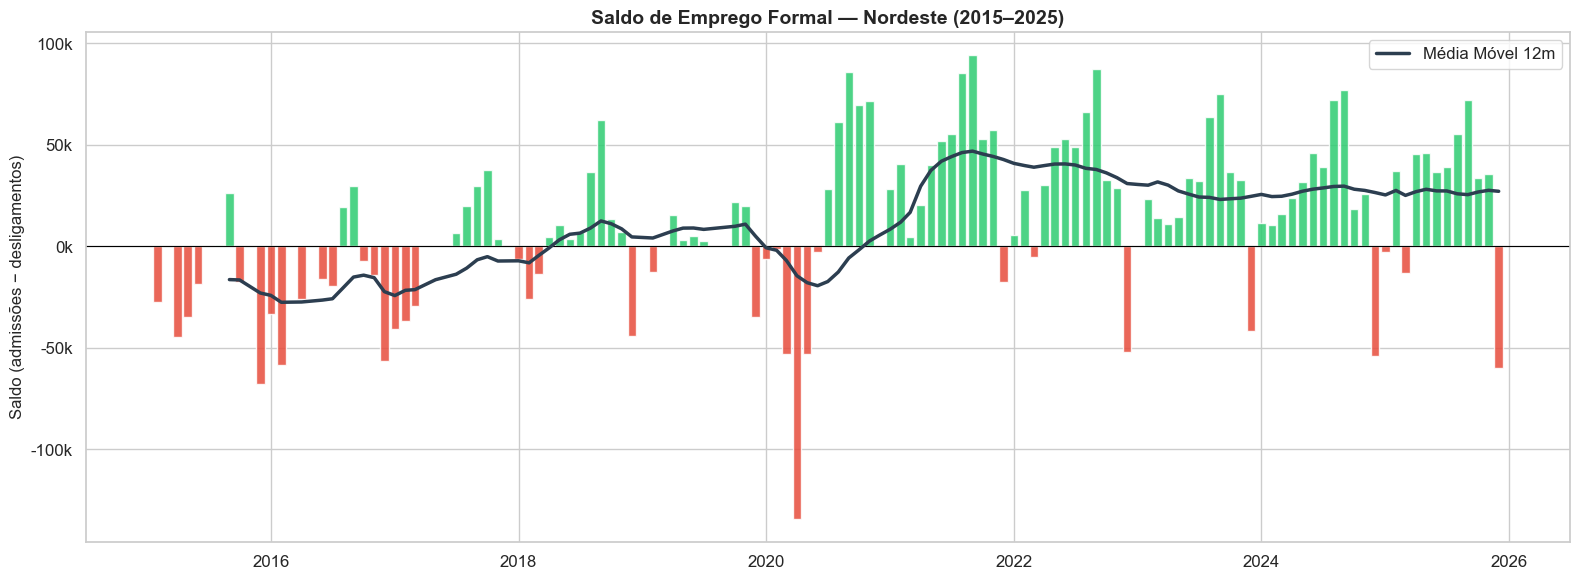

In [2]:
# Saldo agregado mensal do Nordeste
ne_mensal = df_mensal.groupby('data').agg(
    saldo=('saldo', 'sum'),
    admissoes=('admissoes', 'sum'),
    desligamentos=('desligamentos', 'sum'),
    salario_medio=('salario_medio', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in ne_mensal['saldo']]
ax.bar(ne_mensal['data'], ne_mensal['saldo'], color=colors, width=25, alpha=0.85)
ax.axhline(y=0, color='black', linewidth=0.8)

# Média móvel 12 meses
ne_mensal['saldo_mm12'] = ne_mensal['saldo'].rolling(12, min_periods=6).mean()
ax.plot(ne_mensal['data'], ne_mensal['saldo_mm12'], color='#2c3e50', linewidth=2.5, label='Média Móvel 12m')

ax.set_title('Saldo de Emprego Formal — Nordeste (2015–2025)', fontweight='bold')
ax.set_ylabel('Saldo (admissões − desligamentos)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Saldo Acumulado Anual por Estado

Comparação do saldo anual acumulado entre os 9 estados do Nordeste.

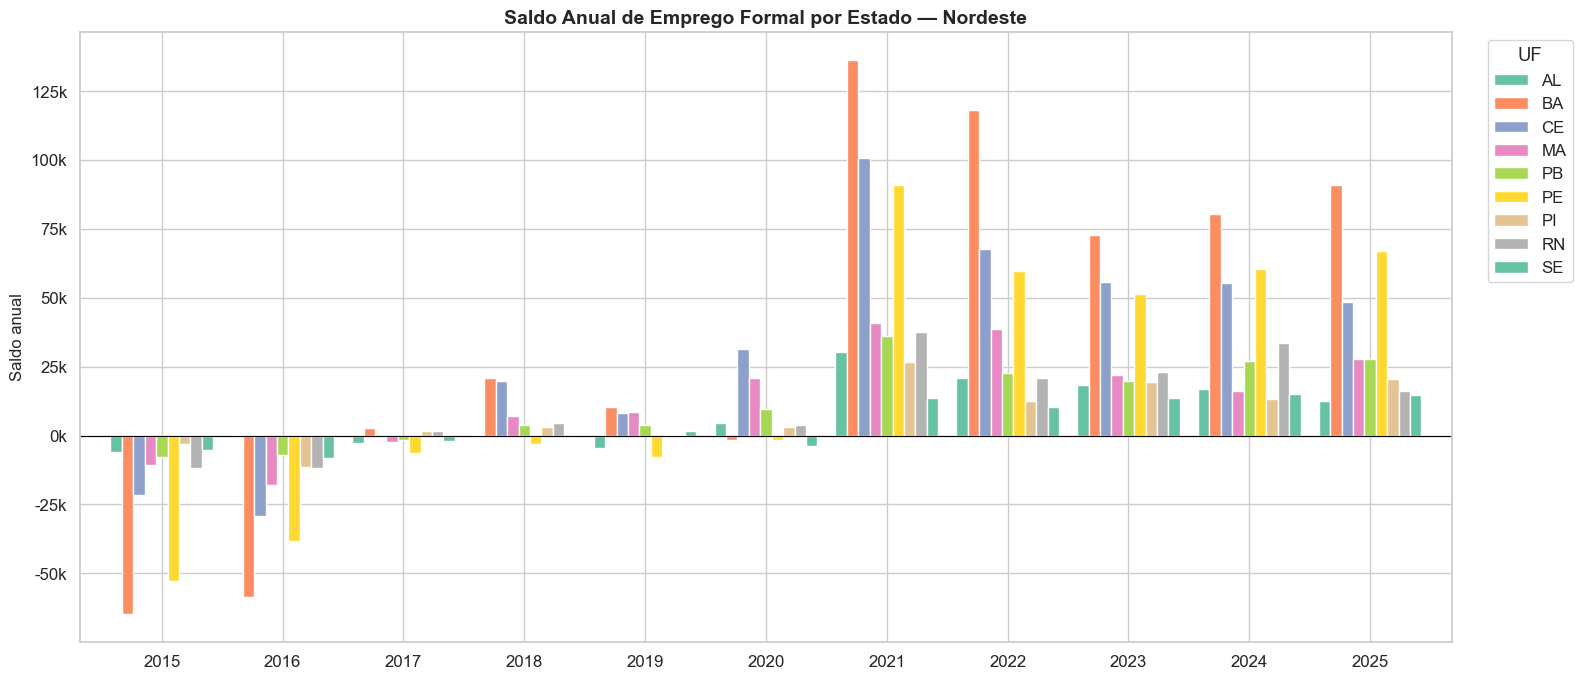

In [3]:
saldo_anual = df_mensal.groupby(['ano', 'sigla_uf'])['saldo'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
pivot = saldo_anual.pivot(index='ano', columns='sigla_uf', values='saldo')
pivot.plot(kind='bar', ax=ax, width=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Saldo Anual de Emprego Formal por Estado — Nordeste', fontweight='bold')
ax.set_ylabel('Saldo anual')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(title='UF', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 3. Heatmap — Saldo Mensal por Estado

Visualização matricial do saldo mensal para identificar padrões sazonais e choques (ex: COVID-19 em 2020).

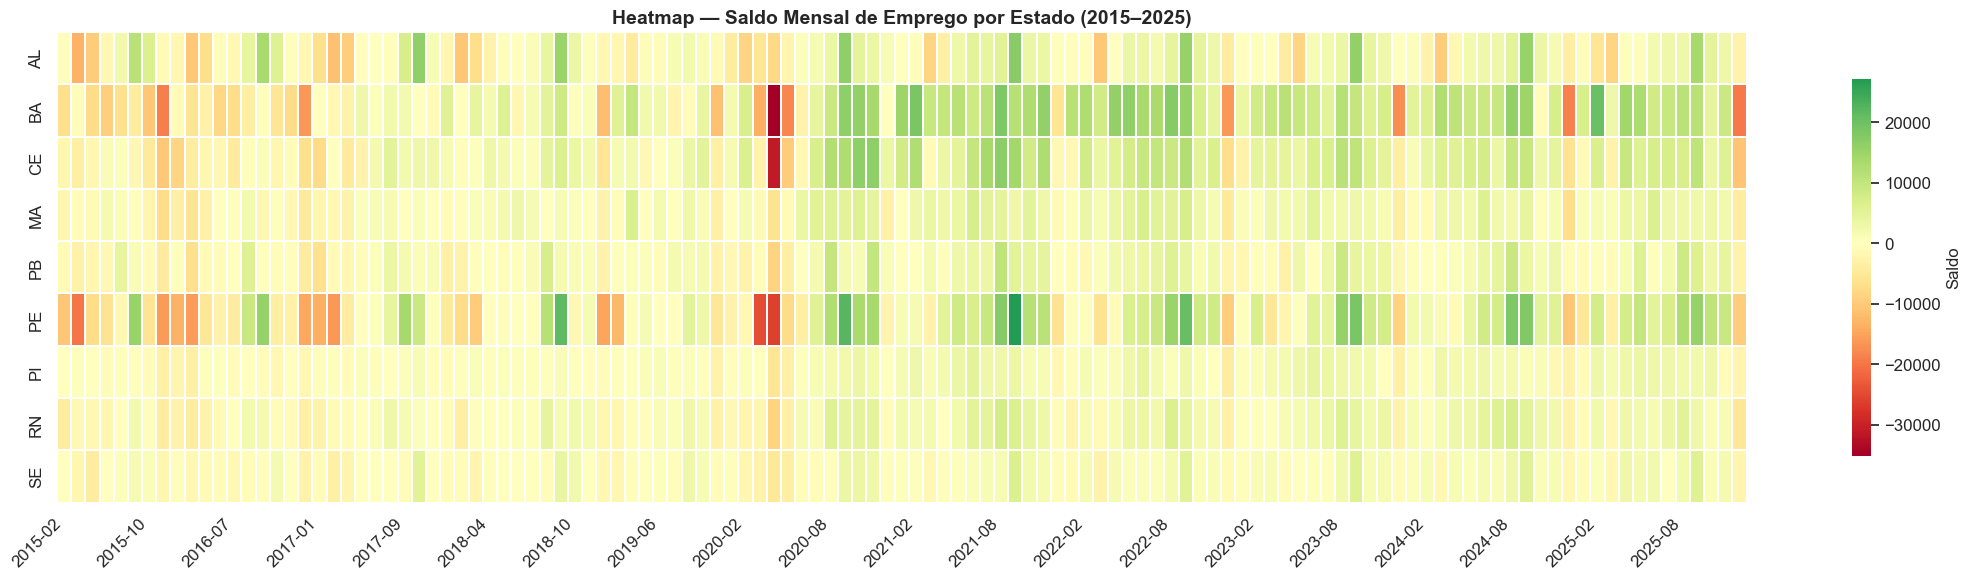

In [4]:
# Criar coluna ano-mês para heatmap
df_mensal['ano_mes'] = df_mensal['data'].dt.strftime('%Y-%m')

# Pivotear para heatmap
heatmap_data = df_mensal.pivot_table(index='sigla_uf', columns='ano_mes', values='saldo', aggfunc='sum')

fig, ax = plt.subplots(figsize=(22, 6))
sns.heatmap(
    heatmap_data, cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.1, cbar_kws={'label': 'Saldo', 'shrink': 0.8},
    xticklabels=6
)
ax.set_title('Heatmap — Saldo Mensal de Emprego por Estado (2015–2025)', fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Evolução do Salário Médio por Estado

Salário médio nominal das movimentações CAGED ao longo do tempo.

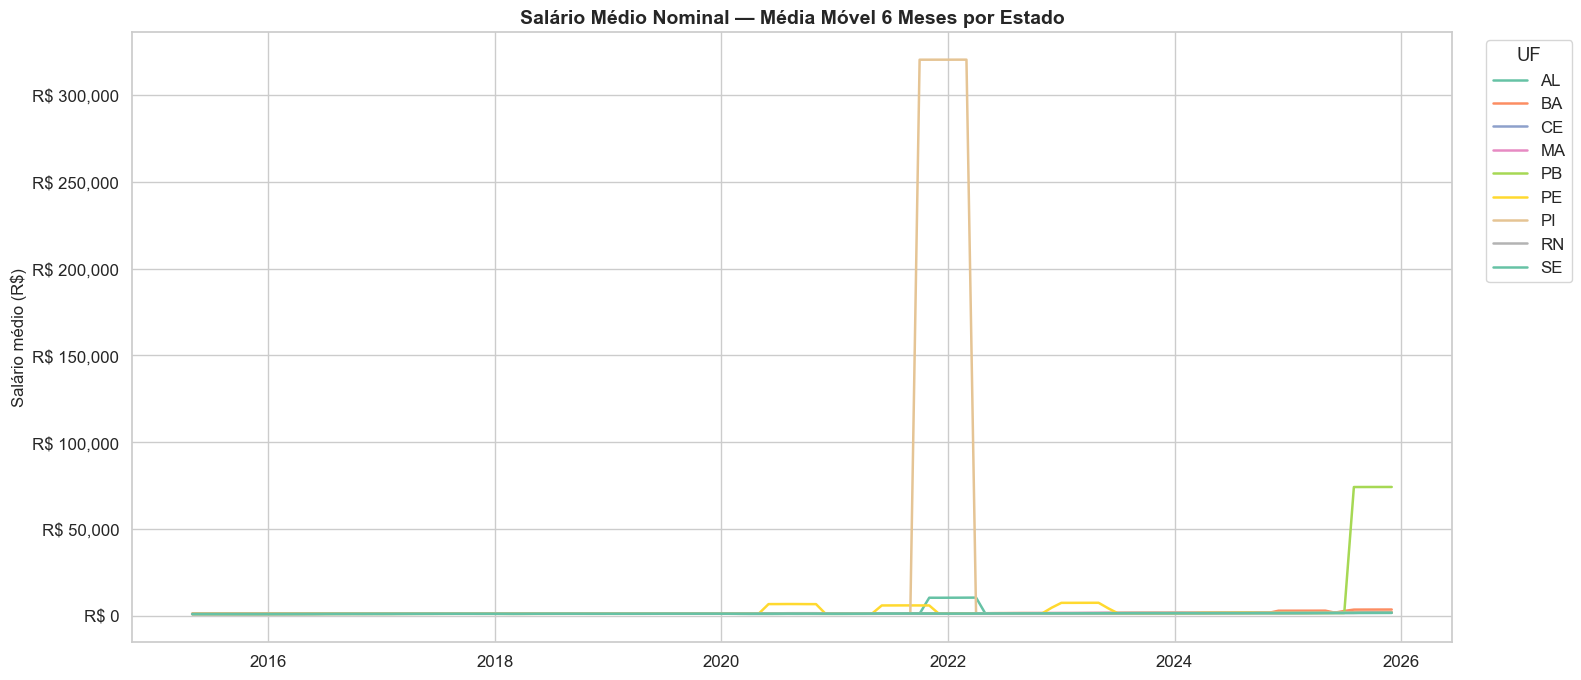

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))

for uf in sorted(df_mensal.sigla_uf.unique()):
    uf_data = df_mensal[df_mensal.sigla_uf == uf].sort_values('data')
    # Média móvel 6 meses para suavizar
    uf_data['sal_mm6'] = uf_data['salario_medio'].rolling(6, min_periods=3).mean()
    ax.plot(uf_data['data'], uf_data['sal_mm6'], label=uf, linewidth=1.8)

ax.set_title('Salário Médio Nominal — Média Móvel 6 Meses por Estado', fontweight='bold')
ax.set_ylabel('Salário médio (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='UF', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Impacto da COVID-19 no Emprego Formal (2020)

Análise do choque no mercado de trabalho durante a pandemia, com foco nos meses de maior impacto.

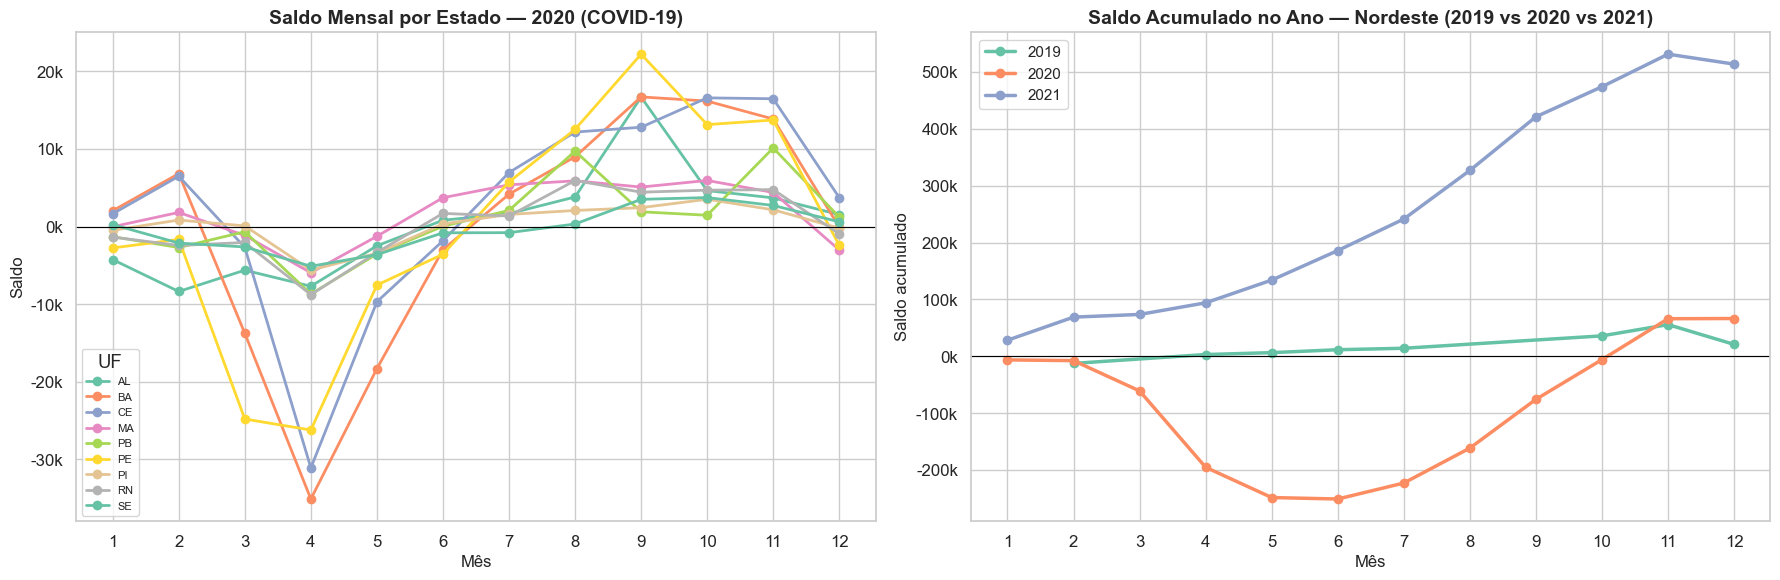

In [6]:
# Saldo mensal por UF em 2020
covid = df_mensal[df_mensal.ano == 2020].copy()
covid_pivot = covid.pivot(index='mes', columns='sigla_uf', values='saldo')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Painel 1: Saldo mensal por UF em 2020
covid_pivot.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Saldo Mensal por Estado — 2020 (COVID-19)', fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Saldo')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].legend(title='UF', fontsize=8)
axes[0].set_xticks(range(1, 13))

# Painel 2: Saldo acumulado do Nordeste - 2019 vs 2020 vs 2021
for year in [2019, 2020, 2021]:
    yr_data = df_mensal[df_mensal.ano == year].groupby('mes')['saldo'].sum().cumsum()
    axes[1].plot(yr_data.index, yr_data.values, marker='o', linewidth=2.5, label=str(year))

axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Saldo Acumulado no Ano — Nordeste (2019 vs 2020 vs 2021)', fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Saldo acumulado')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

---
## 6. Análise por Setor Econômico (Seção CNAE 2.0)

Saldo de emprego por setor econômico no Novo CAGED (2020–2025).

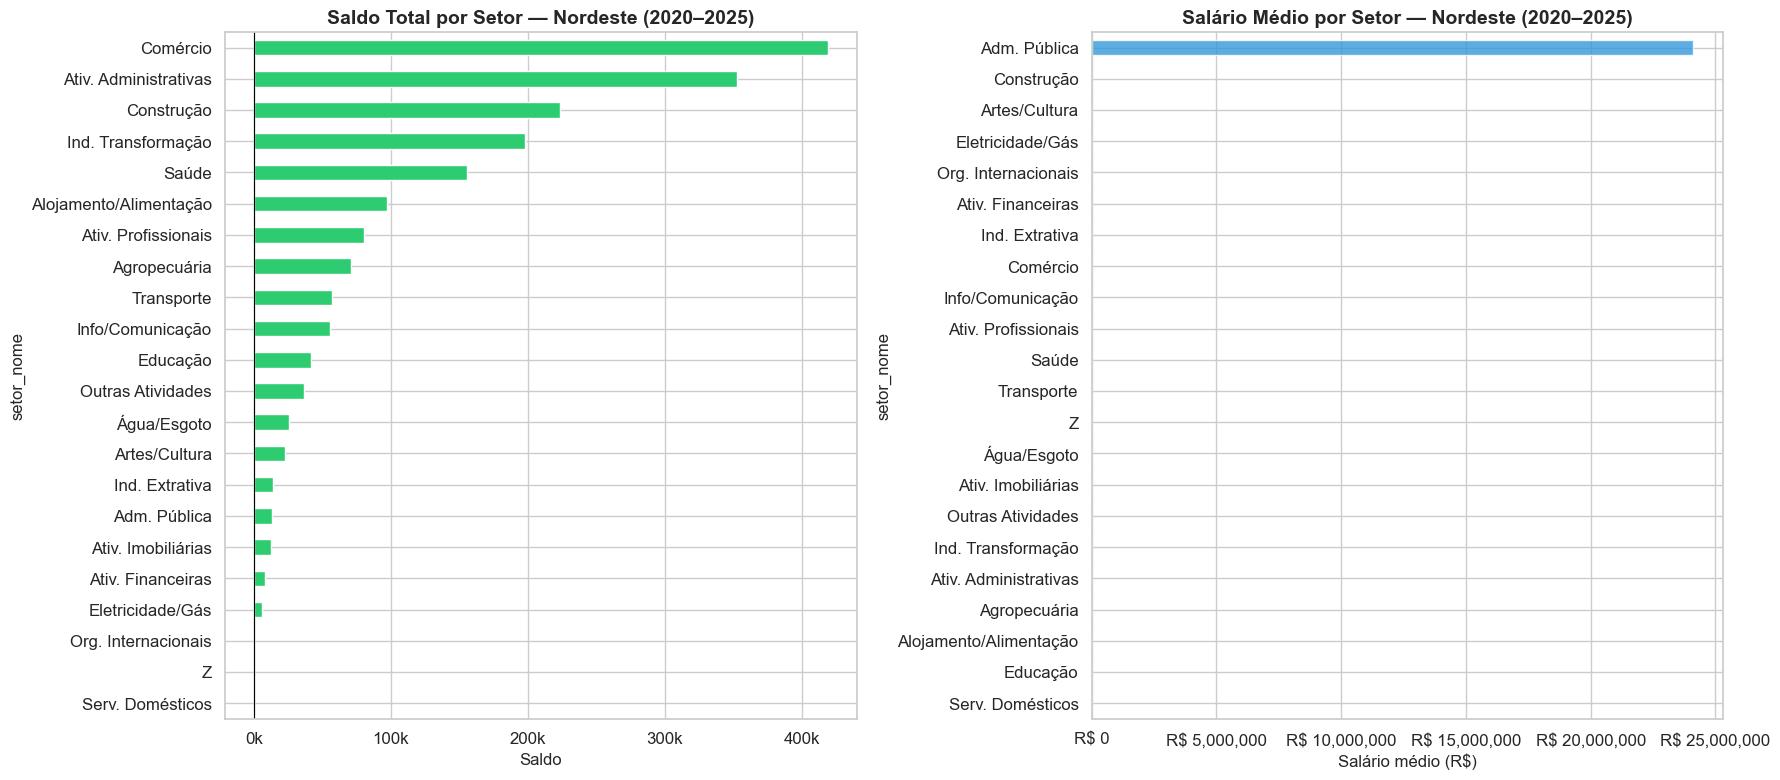

In [7]:
# Mapeamento das seções CNAE
CNAE_SECOES = {
    'A': 'Agropecuária', 'B': 'Ind. Extrativa', 'C': 'Ind. Transformação',
    'D': 'Eletricidade/Gás', 'E': 'Água/Esgoto', 'F': 'Construção',
    'G': 'Comércio', 'H': 'Transporte', 'I': 'Alojamento/Alimentação',
    'J': 'Info/Comunicação', 'K': 'Ativ. Financeiras', 'L': 'Ativ. Imobiliárias',
    'M': 'Ativ. Profissionais', 'N': 'Ativ. Administrativas', 'O': 'Adm. Pública',
    'P': 'Educação', 'Q': 'Saúde', 'R': 'Artes/Cultura',
    'S': 'Outras Atividades', 'T': 'Serv. Domésticos', 'U': 'Org. Internacionais'
}

df_setor['setor_nome'] = df_setor['divisao_cnae'].map(CNAE_SECOES).fillna(df_setor['divisao_cnae'])

# Top setores por saldo total (Nordeste agregado)
setor_total = df_setor.groupby('setor_nome').agg(
    saldo=('saldo', 'sum'),
    salario_medio=('salario_medio', 'mean'),
    movimentacoes=('total_movimentacoes', 'sum')
).sort_values('saldo')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Painel 1: Saldo por setor
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in setor_total['saldo']]
setor_total['saldo'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Saldo Total por Setor — Nordeste (2020–2025)', fontweight='bold')
axes[0].set_xlabel('Saldo')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Painel 2: Salário médio por setor
setor_salario = setor_total.sort_values('salario_medio')
setor_salario['salario_medio'].plot(kind='barh', ax=axes[1], color='#3498db', alpha=0.8)
axes[1].set_title('Salário Médio por Setor — Nordeste (2020–2025)', fontweight='bold')
axes[1].set_xlabel('Salário médio (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

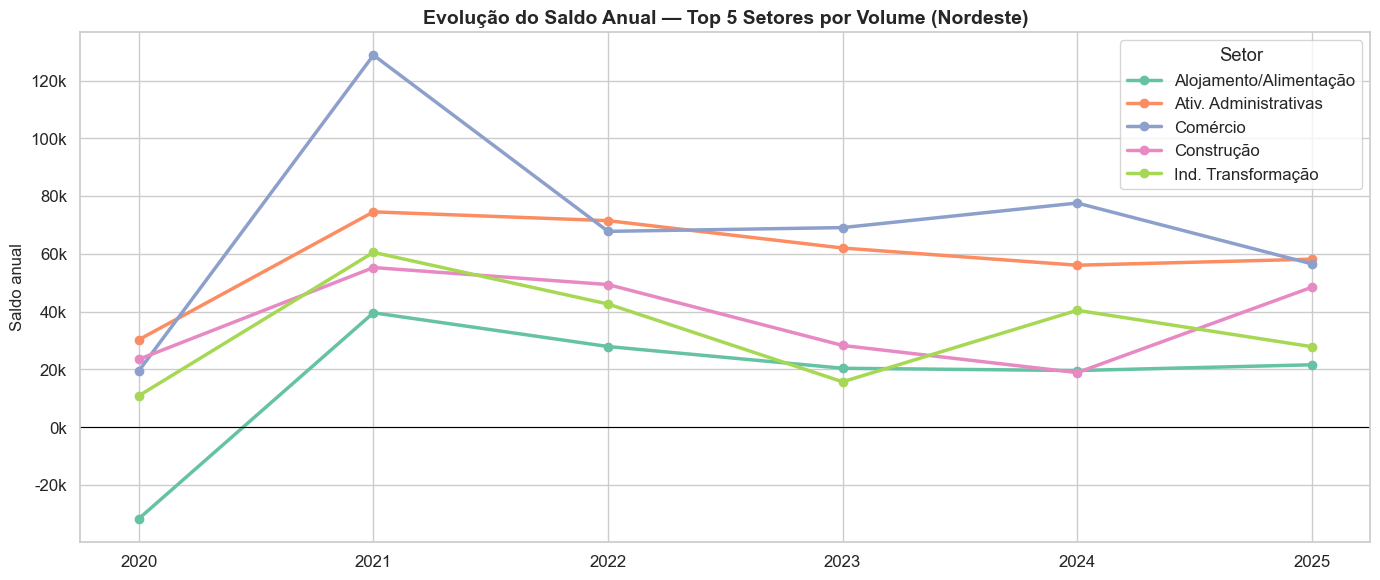

In [8]:
# Evolução anual dos 5 setores com maior volume de movimentações
top5 = df_setor.groupby('divisao_cnae')['total_movimentacoes'].sum().nlargest(5).index
df_top5 = df_setor[df_setor.divisao_cnae.isin(top5)].copy()
df_top5['setor_nome'] = df_top5['divisao_cnae'].map(CNAE_SECOES)

evol_setor = df_top5.groupby(['ano', 'setor_nome'])['saldo'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for setor in evol_setor.setor_nome.unique():
    s = evol_setor[evol_setor.setor_nome == setor]
    ax.plot(s.ano, s.saldo, marker='o', linewidth=2.5, label=setor)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Evolução do Saldo Anual — Top 5 Setores por Volume (Nordeste)', fontweight='bold')
ax.set_ylabel('Saldo anual')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(title='Setor')
plt.tight_layout()
plt.show()

---
## 7. Perfil dos Trabalhadores — Gênero

Análise das admissões, desligamentos e saldo por sexo (1 = Masculino, 2 = Feminino).

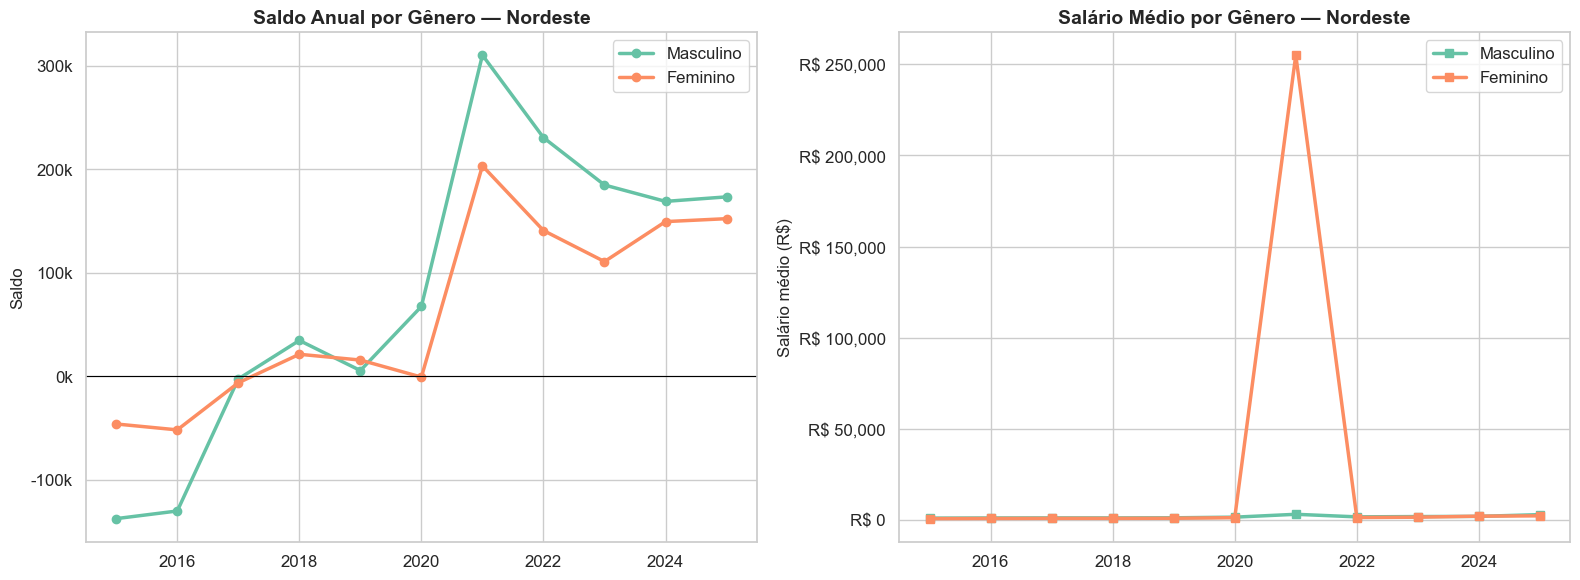


Gap salarial (M vs F) — % acima que homens ganham em relação a mulheres:
sexo_nome  gap_pct
ano               
2015          21.5
2016          20.1
2017          18.0
2018          17.2
2019          17.9
2020          15.8
2021       -7511.5
2022          18.8
2023          16.4
2024          -4.7
2025          20.9


In [9]:
SEXO_MAP = {1: 'Masculino', 2: 'Feminino'}

# Filtrar apenas sexo 1 e 2 (ignorar 9 = não informado)
df_sexo = df_perfil_total[df_perfil_total.sexo.isin([1, 2])].copy()
df_sexo['sexo_nome'] = df_sexo['sexo'].map(SEXO_MAP)

sexo_anual = df_sexo.groupby(['ano', 'sexo_nome']).agg(
    admissoes=('admissoes', 'sum'),
    desligamentos=('desligamentos', 'sum'),
    saldo=('saldo', 'sum'),
    salario_medio=('salario_medio', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Saldo por gênero
for sexo in ['Masculino', 'Feminino']:
    s = sexo_anual[sexo_anual.sexo_nome == sexo]
    axes[0].plot(s.ano, s.saldo, marker='o', linewidth=2.5, label=sexo)

axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Saldo Anual por Gênero — Nordeste', fontweight='bold')
axes[0].set_ylabel('Saldo')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].legend()

# Salário médio por gênero
for sexo in ['Masculino', 'Feminino']:
    s = sexo_anual[sexo_anual.sexo_nome == sexo]
    axes[1].plot(s.ano, s.salario_medio, marker='s', linewidth=2.5, label=sexo)

axes[1].set_title('Salário Médio por Gênero — Nordeste', fontweight='bold')
axes[1].set_ylabel('Salário médio (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.show()

# Gap salarial
gap = sexo_anual.pivot(index='ano', columns='sexo_nome', values='salario_medio')
gap['gap_pct'] = ((gap['Masculino'] - gap['Feminino']) / gap['Masculino'] * 100).round(1)
print('\nGap salarial (M vs F) — % acima que homens ganham em relação a mulheres:')
print(gap[['gap_pct']].to_string())

---
## 8. Perfil dos Trabalhadores — Escolaridade

Distribuição das movimentações por grau de instrução.

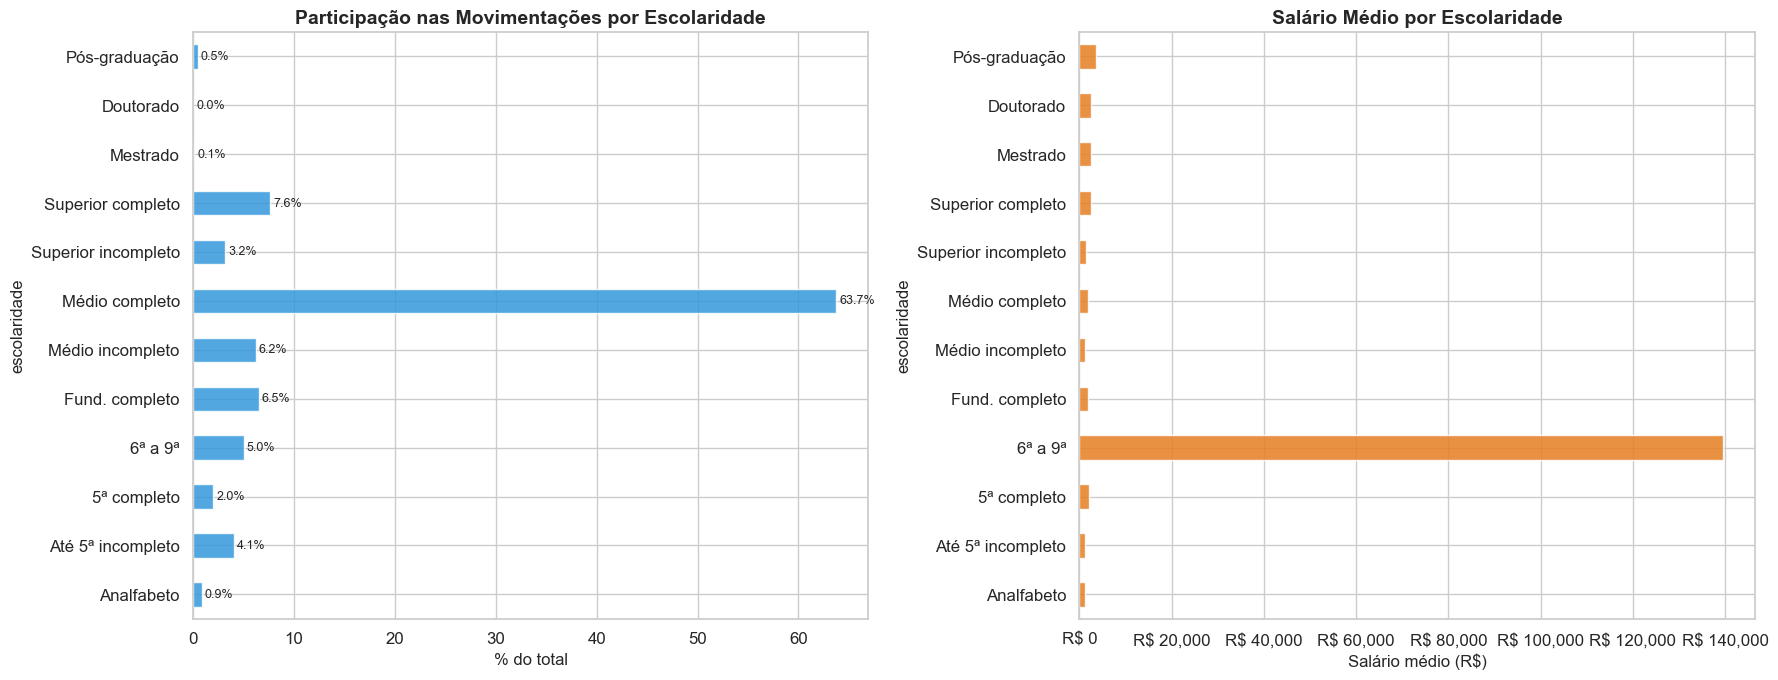

In [10]:
GRAU_MAP = {
    1: 'Analfabeto', 2: 'Até 5ª incompleto', 3: '5ª completo',
    4: '6ª a 9ª', 5: 'Fund. completo', 6: 'Médio incompleto',
    7: 'Médio completo', 8: 'Superior incompleto', 9: 'Superior completo',
    10: 'Mestrado', 11: 'Doutorado', 80: 'Pós-graduação'
}

df_esc = df_perfil_total[df_perfil_total.grau_instrucao.isin(GRAU_MAP.keys())].copy()
df_esc['escolaridade'] = df_esc['grau_instrucao'].map(GRAU_MAP)

# Ordem lógica para grau de instrução
ordem = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 80]
ordem_nomes = [GRAU_MAP[g] for g in ordem]

# Total de movimentações por escolaridade (todo período)
esc_total = df_esc.groupby('escolaridade').agg(
    saldo=('saldo', 'sum'),
    movimentacoes=('total_movimentacoes', 'sum'),
    salario_medio=('salario_medio', 'mean')
).reindex(ordem_nomes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Participação nas movimentações
esc_total['pct'] = esc_total['movimentacoes'] / esc_total['movimentacoes'].sum() * 100
esc_total['pct'].plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.85)
axes[0].set_title('Participação nas Movimentações por Escolaridade', fontweight='bold')
axes[0].set_xlabel('% do total')
for i, v in enumerate(esc_total['pct']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Salário médio por escolaridade
esc_total['salario_medio'].plot(kind='barh', ax=axes[1], color='#e67e22', alpha=0.85)
axes[1].set_title('Salário Médio por Escolaridade', fontweight='bold')
axes[1].set_xlabel('Salário médio (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 9. Série Bimestral Harmonizada (2015–2025)

A série bimestral permite comparação consistente entre o CAGED Antigo e o Novo CAGED, eliminando diferenças de periodicidade.

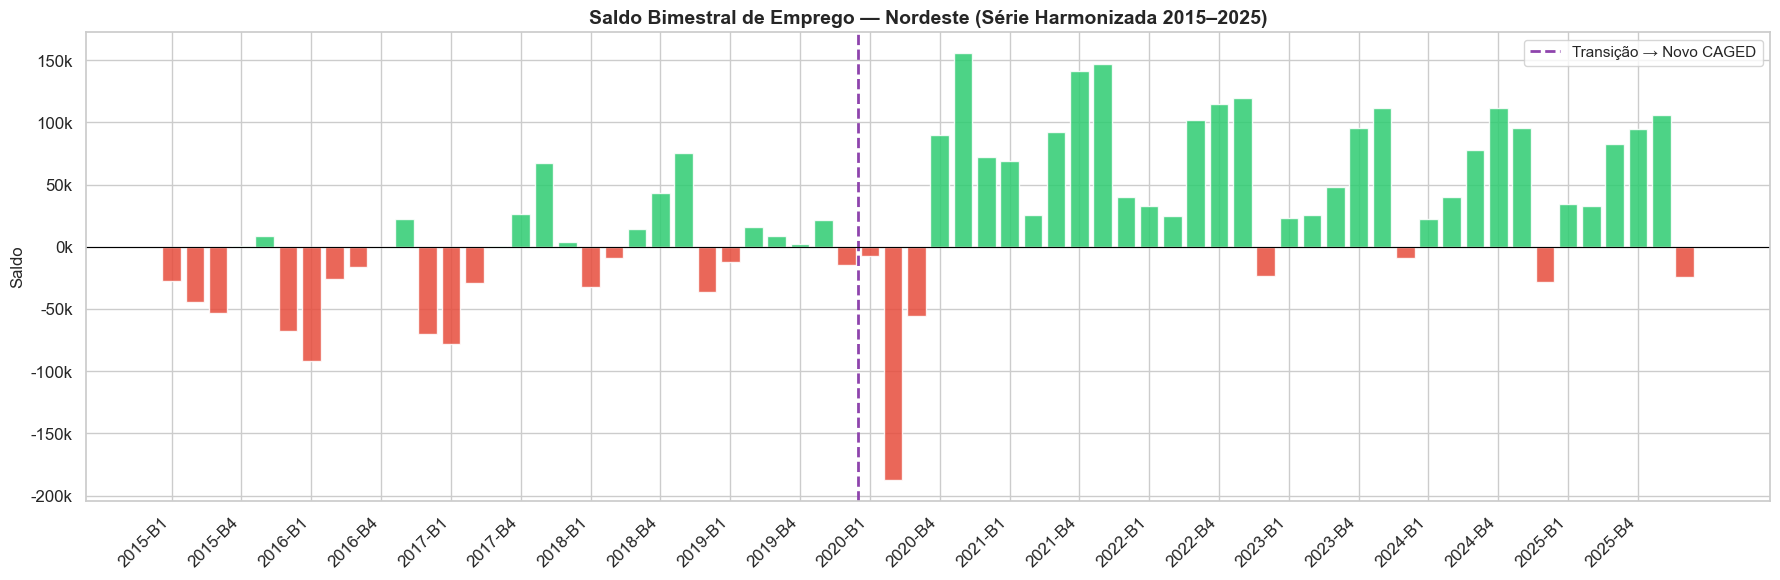

In [11]:
# Saldo bimestral agregado Nordeste
bim_ne = df_bimestral.groupby(['ano_bim', 'bimestre']).agg(
    saldo=('saldo', 'sum'),
    admissoes=('admissoes', 'sum'),
    desligamentos=('desligamentos', 'sum')
).reset_index()

# Criar índice temporal
bim_ne['periodo'] = bim_ne['ano_bim'].astype(str) + '-B' + bim_ne['bimestre'].astype(str)
bim_ne = bim_ne.sort_values(['ano_bim', 'bimestre'])

fig, ax = plt.subplots(figsize=(18, 6))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in bim_ne['saldo']]
bars = ax.bar(range(len(bim_ne)), bim_ne['saldo'], color=colors, alpha=0.85)

# Linha de transição CAGED Antigo → Novo
transicao_idx = bim_ne[bim_ne.ano_bim == 2020].index[0] - bim_ne.index[0]
ax.axvline(x=transicao_idx - 0.5, color='#8e44ad', linewidth=2, linestyle='--', label='Transição → Novo CAGED')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Saldo Bimestral de Emprego — Nordeste (Série Harmonizada 2015–2025)', fontweight='bold')
ax.set_ylabel('Saldo')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Rótulos do eixo X
tick_positions = list(range(0, len(bim_ne), 3))
tick_labels = [bim_ne.iloc[i]['periodo'] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 10. Ranking dos Estados — Desempenho Consolidado

Comparação dos estados por saldo total, salário médio e volume de movimentações no período completo.

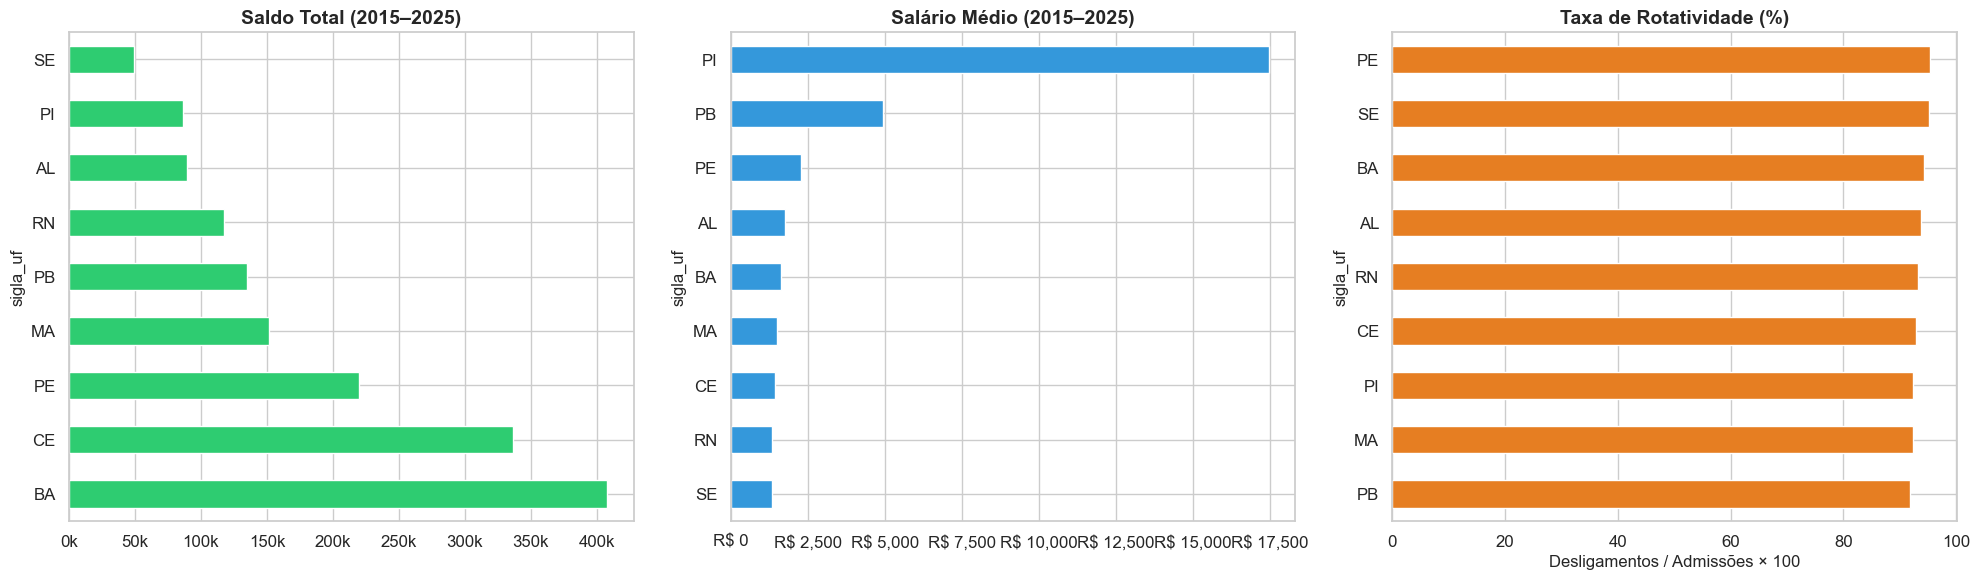


Resumo por Estado (2015–2025):
          saldo_total  admissoes_total  desligamentos_total  salario_medio  taxa_rotatividade
sigla_uf                                                                                     
BA             407516          7201706              6794190        1,645.4               94.3
CE             336092          4712012              4375920        1,426.5               92.9
PE             219739          4823289              4603550        2,275.1               95.4
MA             151378          1963900              1812522        1,496.0               92.3
PB             134553          1649066              1514513        4,949.9               91.8
RN             117746          1765810              1648064        1,343.0               93.3
AL              89552          1440693              1351141        1,769.2               93.8
PI              86466          1136618              1050152       17,449.9               92.4
SE              49583       

In [12]:
ranking = df_mensal.groupby('sigla_uf').agg(
    saldo_total=('saldo', 'sum'),
    admissoes_total=('admissoes', 'sum'),
    desligamentos_total=('desligamentos', 'sum'),
    salario_medio=('salario_medio', 'mean'),
    movimentacoes=('total_movimentacoes', 'sum')
).sort_values('saldo_total', ascending=False)

ranking['taxa_rotatividade'] = (
    (ranking['desligamentos_total'] / ranking['admissoes_total']) * 100
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Saldo total
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in ranking['saldo_total']]
ranking['saldo_total'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Saldo Total (2015–2025)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Salário médio
ranking.sort_values('salario_medio')['salario_medio'].plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Salário Médio (2015–2025)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

# Taxa de rotatividade
ranking.sort_values('taxa_rotatividade')['taxa_rotatividade'].plot(kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('Taxa de Rotatividade (%)', fontweight='bold')
axes[2].set_xlabel('Desligamentos / Admissões × 100')

plt.tight_layout()
plt.show()

print('\nResumo por Estado (2015–2025):')
display_cols = ['saldo_total', 'admissoes_total', 'desligamentos_total', 'salario_medio', 'taxa_rotatividade']
print(ranking[display_cols].to_string(float_format='{:,.1f}'.format))

---
## 11. Sazonalidade do Emprego Formal

Padrão sazonal médio por mês, calculado sobre todo o período disponível.

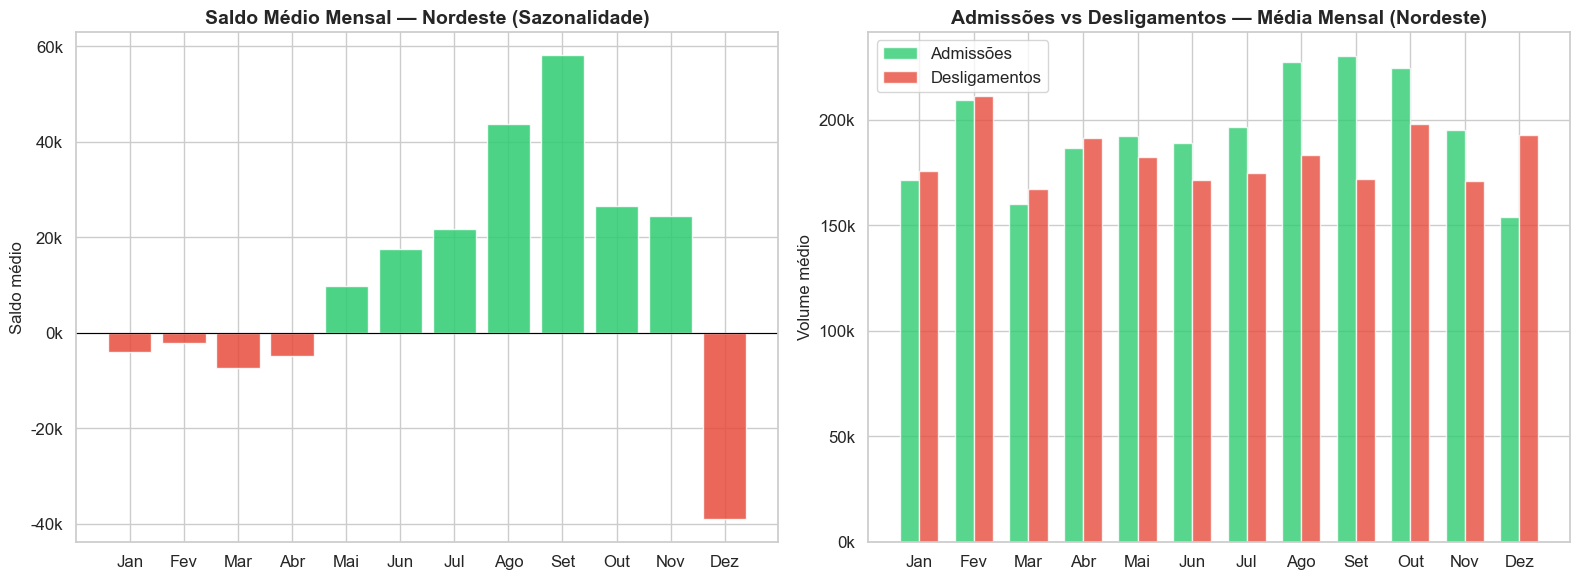

In [13]:
# Sazonalidade média do Nordeste
sazon = df_mensal.groupby('mes').agg(
    saldo_medio=('saldo', 'mean'),
    saldo_mediano=('saldo', 'median'),
    admissoes=('admissoes', 'mean'),
    desligamentos=('desligamentos', 'mean')
).reset_index()

# Agregar por UF primeiro e depois calcular por mês
sazon_ne = df_mensal.groupby(['mes']).agg(
    saldo=('saldo', 'sum')
).reset_index()
n_anos = df_mensal.ano.nunique()
sazon_ne['saldo_medio'] = sazon_ne['saldo'] / n_anos

meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Saldo médio por mês
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sazon_ne['saldo_medio']]
axes[0].bar(sazon_ne['mes'], sazon_ne['saldo_medio'], color=colors, alpha=0.85)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Saldo Médio Mensal — Nordeste (Sazonalidade)', fontweight='bold')
axes[0].set_ylabel('Saldo médio')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_nomes)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Admissões vs Desligamentos por mês
adm_desl_mes = df_mensal.groupby('mes').agg(
    admissoes=('admissoes', 'sum'),
    desligamentos=('desligamentos', 'sum')
).reset_index()
adm_desl_mes['admissoes'] = adm_desl_mes['admissoes'] / n_anos
adm_desl_mes['desligamentos'] = adm_desl_mes['desligamentos'] / n_anos

x = range(1, 13)
w = 0.35
axes[1].bar([i - w/2 for i in x], adm_desl_mes['admissoes'], w, label='Admissões', color='#2ecc71', alpha=0.8)
axes[1].bar([i + w/2 for i in x], adm_desl_mes['desligamentos'], w, label='Desligamentos', color='#e74c3c', alpha=0.8)
axes[1].set_title('Admissões vs Desligamentos — Média Mensal (Nordeste)', fontweight='bold')
axes[1].set_ylabel('Volume médio')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_nomes)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 12. Tabela Resumo — Estatísticas Descritivas

Estatísticas descritivas dos principais indicadores por estado.

In [14]:
# Estatísticas descritivas por UF
resumo = df_mensal.groupby('sigla_uf').agg(
    saldo_total=('saldo', 'sum'),
    saldo_medio_mensal=('saldo', 'mean'),
    saldo_desvio=('saldo', 'std'),
    meses_positivos=('saldo', lambda x: (x > 0).sum()),
    meses_negativos=('saldo', lambda x: (x < 0).sum()),
    salario_medio=('salario_medio', 'mean'),
    salario_min=('salario_medio', 'min'),
    salario_max=('salario_medio', 'max'),
    pior_mes=('saldo', 'min'),
    melhor_mes=('saldo', 'max'),
    total_movimentacoes=('total_movimentacoes', 'sum')
).round(1)

n_meses = df_mensal.groupby('sigla_uf').size()
resumo['pct_meses_positivos'] = (resumo['meses_positivos'] / n_meses * 100).round(1)

print('Estatísticas Descritivas por Estado (2015–2025)')
print('=' * 100)
resumo_display = resumo[[
    'saldo_total', 'saldo_medio_mensal', 'saldo_desvio',
    'pct_meses_positivos', 'salario_medio',
    'pior_mes', 'melhor_mes', 'total_movimentacoes'
]].rename(columns={
    'saldo_total': 'Saldo Total',
    'saldo_medio_mensal': 'Saldo Médio/Mês',
    'saldo_desvio': 'Desvio Padrão',
    'pct_meses_positivos': '% Meses Positivos',
    'salario_medio': 'Salário Médio (R$)',
    'pior_mes': 'Pior Mês',
    'melhor_mes': 'Melhor Mês',
    'total_movimentacoes': 'Total Movimentações'
})
print(resumo_display.to_string(float_format='{:,.1f}'.format))

Estatísticas Descritivas por Estado (2015–2025)
          Saldo Total  Saldo Médio/Mês  Desvio Padrão  % Meses Positivos  Salário Médio (R$)  Pior Mês  Melhor Mês  Total Movimentações
sigla_uf                                                                                                                               
AL              89552            752.5        6,127.8               55.5             1,769.2    -13269       16978              2791834
BA             407516          3,424.5        9,878.0               66.4             1,645.4    -35098       20132             13995896
CE             336092          2,824.3        6,627.3               69.7             1,426.5    -31085       16773              9087932
MA             151378          1,272.1        3,047.1               68.9             1,496.0     -7324        7082              3776422
PB             134553          1,130.7        3,311.3               62.2             4,949.9     -8693       10555              3163579
